# Import Library

In [1]:
import os
import cv2
import numpy as np
from sklearn.utils import shuffle
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score

# Get Data

In [2]:
labels = ['Covid19', 'Normal', 'Pneumonia']
img_size = 224

def get_data(data_dir):
    data = []
    for label in labels:
        path = os.path.join(data_dir, label)
        class_num = labels.index(label)
        for img in os.listdir(path):
            try:
                img_path = os.path.join(path, img)
                img_arr = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                if img_arr is not None:
                    resized_arr = cv2.resize(img_arr, (img_size, img_size))
                    data.append([resized_arr, class_num])
            except Exception as e:
                print(f"Error reading {img_path}: {e}")
    return data

train = shuffle(get_data("/kaggle/input/train-covid19-pneumonia-normal/Train_COVID19_Pneumonia_Normal/train"))
val   = shuffle(get_data("/kaggle/input/train-covid19-pneumonia-normal/Train_COVID19_Pneumonia_Normal/val"))

# Dataset Preparation

In [3]:
class CovidDataset(Dataset):
    def __init__(self, data):
        self.x = np.array([i[0] for i in data])
        self.y = np.array([i[1] for i in data])

        self.transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((224, 224)),
            transforms.Lambda(lambda image: image.convert("RGB")),
            transforms.ToTensor(),
        ])

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        img = self.x[idx]
        img = self.transform(img)
        label = torch.tensor(self.y[idx]).long()
        return img, label

In [4]:
train_dataset = CovidDataset(train)
val_dataset = CovidDataset(val)

dataloaders = {
    'train': DataLoader(train_dataset, batch_size=32, shuffle=True),
    'val': DataLoader(val_dataset, batch_size=32, shuffle=False),
}

dataset_sizes = {
    'train': len(train_dataset),
    'val': len(val_dataset),
}

# Model

In [15]:
!pip install torchsummary

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = models.densenet169(pretrained=True)

# Replace classifier
num_ftrs = model.classifier.in_features
model.classifier = nn.Linear(num_ftrs, 3)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer_ft = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet169_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet169_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/densenet169-b2777c0a.pth" to /root/.cache/torch/hub/checkpoints/densenet169-b2777c0a.pth
100%|██████████| 54.7M/54.7M [00:00<00:00, 187MB/s] 


# Train model

In [6]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=10):
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")

        for phase in ['train', 'val']:
            model.train() if phase == 'train' else model.eval()
            
            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs, labels = inputs.to(device), labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels)

            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f"{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

            # ✅ LƯU LOSS & ACC
            if phase == 'train':
                train_losses.append(epoch_loss)
                train_accs.append(epoch_acc.item())
            else:
                val_losses.append(epoch_loss)
                val_accs.append(epoch_acc.item())

    return model, train_losses, val_losses, train_accs, val_accs


In [7]:
model, train_losses, val_losses, train_accs, val_accs = train_model(
    model, criterion, optimizer_ft, exp_lr_scheduler, num_epochs=2
)


Epoch 1/2
train Loss: 0.1533 Acc: 0.9447
val Loss: 0.0716 Acc: 0.9813

Epoch 2/2
train Loss: 0.0361 Acc: 0.9889
val Loss: 0.0392 Acc: 0.9910


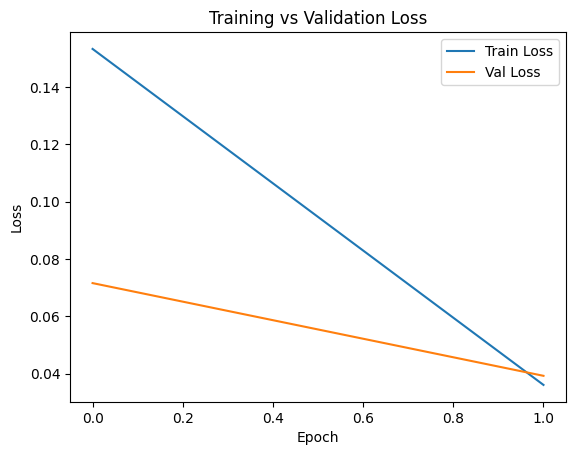

In [8]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training vs Validation Loss')
plt.show()


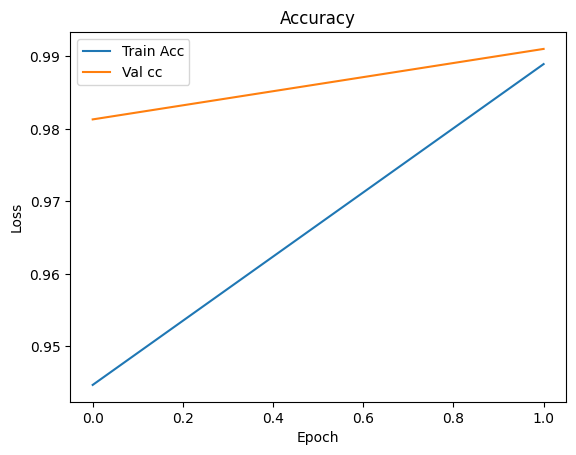

In [10]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Accuracy')
plt.show()


# Inference

In [30]:
test = shuffle(get_data("/kaggle/input/test-covid19-pneumonia-normal/Test_COVID19_Pneumonia_Normal/test"))

test_dataset = CovidDataset(test)

test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Test samples:", len(test_dataset))

Test samples: 4020


In [31]:
def evaluate(model, dataloader):
    model.eval()
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            correct += torch.sum(preds == labels).item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = correct / total
    print(f"\nTest Accuracy: {accuracy:.4f}")

    return all_labels, all_preds

In [27]:
torch.save(model.state_dict(), "densenet169.pth")
print("Model saved!")

Model saved!


In [33]:
# Load model architecture
loaded_model = models.densenet169(pretrained=False)
num_ftrs = loaded_model.classifier.in_features
loaded_model.classifier = nn.Linear(num_ftrs, 3)   # correct final layer for DenseNet

# Load weights
loaded_model.load_state_dict(torch.load("densenet169.pth", map_location=device))
loaded_model = loaded_model.to(device)
loaded_model.eval()

print("Model loaded successfully!")


Model loaded successfully!


In [34]:
labels_test, preds_test = evaluate(loaded_model, test_loader)


Test Accuracy: 0.9915


In [35]:
precision_macro = precision_score(labels_test, preds_test, average="macro")
recall_macro    = recall_score(labels_test, preds_test, average="macro")
f1_macro        = f1_score(labels_test, preds_test, average="macro")

print("Macro Precision:", precision_macro)
print("Macro Recall   :", recall_macro)
print("Macro F1-score :", f1_macro)


Macro Precision: 0.9922904237348283
Macro Recall   : 0.9891997086222807
Macro F1-score : 0.9907209587436262


# Visualization

In [36]:
label_names = ['Pneumonia', 'Normal', 'Covid19']

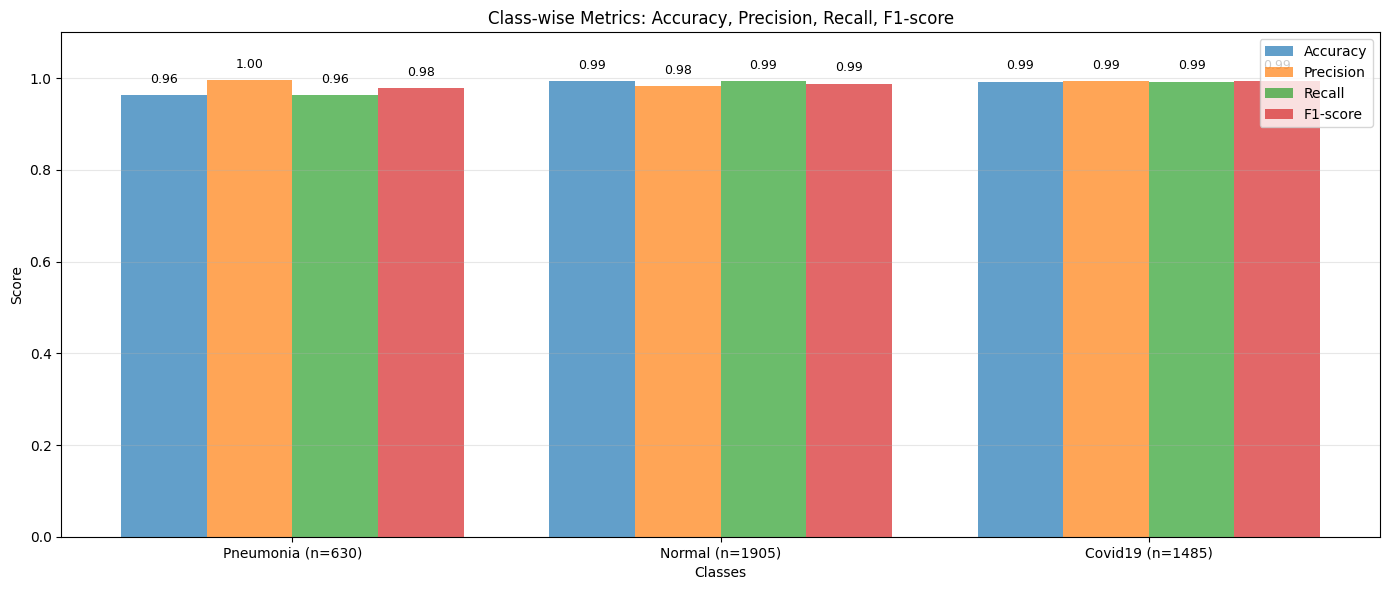

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

label_names = ['Pneumonia', 'Normal', 'Covid19']

def plot_classwise_metrics(y_true, y_pred, class_names):
    """
    Vẽ biểu đồ class-wise metrics: Accuracy, Precision, Recall, F1-score
    """
    # --- FIX: chuẩn hoá về vector nhãn 1D ---
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    # nếu y_true/y_pred là one-hot/prob (N,C) -> argmax
    if y_true.ndim == 2 and y_true.shape[1] > 1:
        y_true = np.argmax(y_true, axis=1)
    if y_pred.ndim == 2 and y_pred.shape[1] > 1:
        y_pred = np.argmax(y_pred, axis=1)

    # nếu (N,1) -> flatten, nếu scalar -> thành (1,)
    y_true = np.ravel(y_true)
    y_pred = np.ravel(y_pred)

    if y_true.shape[0] != y_pred.shape[0]:
        raise ValueError(f"y_true và y_pred khác số lượng phần tử: {y_true.shape[0]} vs {y_pred.shape[0]}")

    n_classes = len(class_names)

    # Tính metrics cho từng lớp (average=None trả về mảng theo từng class)
    precisions = precision_score(y_true, y_pred, average=None, labels=range(n_classes), zero_division=0)
    recalls    = recall_score(y_true, y_pred, average=None, labels=range(n_classes), zero_division=0)
    f1_scores  = f1_score(y_true, y_pred, average=None, labels=range(n_classes), zero_division=0)

    # Accuracy per class (đúng theo subset của class đó)
    accuracies = []
    class_counts = []
    for i in range(n_classes):
        class_mask = (y_true == i)
        class_true = y_true[class_mask]
        class_pred = y_pred[class_mask]

        acc = accuracy_score(class_true, class_pred) if class_true.size > 0 else 0
        accuracies.append(acc)
        class_counts.append(class_true.size)

    # Vẽ biểu đồ
    x = np.arange(n_classes)
    width = 0.2

    plt.figure(figsize=(14,6))
    plt.bar(x - 1.5*width, accuracies, width, label='Accuracy', alpha=0.7)
    plt.bar(x - 0.5*width, precisions, width, label='Precision', alpha=0.7)
    plt.bar(x + 0.5*width, recalls, width, label='Recall', alpha=0.7)
    plt.bar(x + 1.5*width, f1_scores, width, label='F1-score', alpha=0.7)

    # Thêm nhãn giá trị
    for i in range(n_classes):
        plt.text(x[i] - 1.5*width, accuracies[i] + 0.02, f'{accuracies[i]:.2f}', ha='center', va='bottom', fontsize=9)
        plt.text(x[i] - 0.5*width, precisions[i] + 0.02, f'{precisions[i]:.2f}', ha='center', va='bottom', fontsize=9)
        plt.text(x[i] + 0.5*width, recalls[i] + 0.02, f'{recalls[i]:.2f}', ha='center', va='bottom', fontsize=9)
        plt.text(x[i] + 1.5*width, f1_scores[i] + 0.02, f'{f1_scores[i]:.2f}', ha='center', va='bottom', fontsize=9)

    xtick_labels = [f"{name} (n={count})" for name, count in zip(class_names, class_counts)]
    plt.xticks(x, xtick_labels, rotation=0, ha='center')
    plt.ylim(0, 1.1)
    plt.xlabel('Classes')
    plt.ylabel('Score')
    plt.title('Class-wise Metrics: Accuracy, Precision, Recall, F1-score')
    plt.grid(axis='y', alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return accuracies, precisions, recalls, f1_scores, class_counts

# Sử dụng:
accuracies, precisions, recalls, f1_scores, counts = plot_classwise_metrics(labels_test, preds_test, label_names)


# Confusion matrix

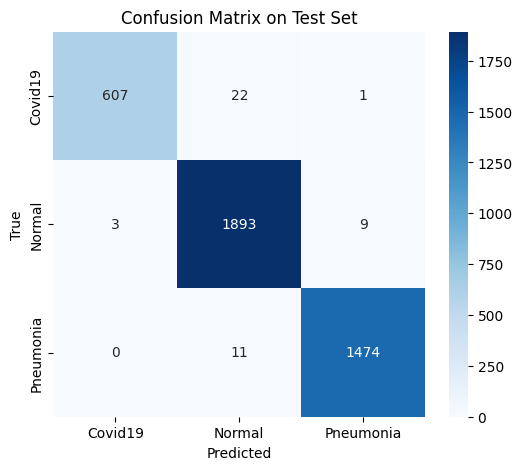

In [13]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(labels_test, preds_test)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix on Test Set")
plt.show()

In [28]:
import torch.nn.functional as F
model.eval()

all_logits = []
all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)                  # (B, C)
        probs  = F.softmax(logits, dim=1)       # (B, C)

        all_logits.append(logits.cpu())
        all_probs.append(probs.cpu())
        all_labels.append(labels.cpu())

logits_test = torch.cat(all_logits, dim=0)     # (N, C)
probs_test  = torch.cat(all_probs, dim=0)      # (N, C)
labels_test = torch.cat(all_labels, dim=0)     # (N,)
preds_test  = torch.argmax(probs_test, dim=1) # (N,)

print("Shapes:")
print("logits:", logits_test.shape)
print("probs :", probs_test.shape)
print("labels:", labels_test.shape)

Shapes:
logits: torch.Size([4020, 3])
probs : torch.Size([4020, 3])
labels: torch.Size([4020])


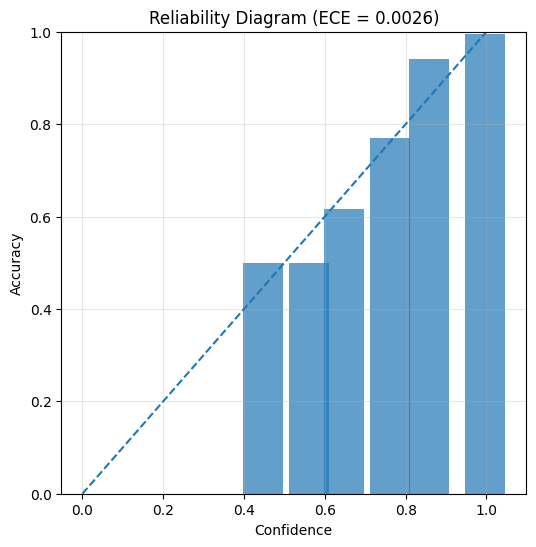

ECE: 0.0025726046505852264


In [29]:
import matplotlib.pyplot as plt
import numpy as np

def plot_reliability_diagram(y_true, y_prob, n_bins=10):
    y_true = y_true.numpy()
    y_prob = y_prob.numpy()

    conf = np.max(y_prob, axis=1)
    preds = np.argmax(y_prob, axis=1)
    acc = (preds == y_true).astype(float)

    bins = np.linspace(0, 1, n_bins + 1)
    bin_ids = np.digitize(conf, bins) - 1

    bin_acc, bin_conf, bin_count = [], [], []
    ece = 0.0

    for i in range(n_bins):
        mask = bin_ids == i
        count = np.sum(mask)
        bin_count.append(count)

        if count > 0:
            a = np.mean(acc[mask])
            c = np.mean(conf[mask])
            bin_acc.append(a)
            bin_conf.append(c)
            ece += (count / len(y_true)) * abs(a - c)
        else:
            bin_acc.append(0)
            bin_conf.append((bins[i] + bins[i+1]) / 2)

    plt.figure(figsize=(6,6))
    plt.plot([0,1], [0,1], linestyle='--')
    plt.bar(bin_conf, bin_acc, width=1/n_bins, alpha=0.7)
    plt.xlabel("Confidence")
    plt.ylabel("Accuracy")
    plt.title(f"Reliability Diagram (ECE = {ece:.4f})")
    plt.ylim(0,1)
    plt.grid(alpha=0.3)
    plt.show()

    return ece

ece = plot_reliability_diagram(labels_test, probs_test)
print("ECE:", ece)


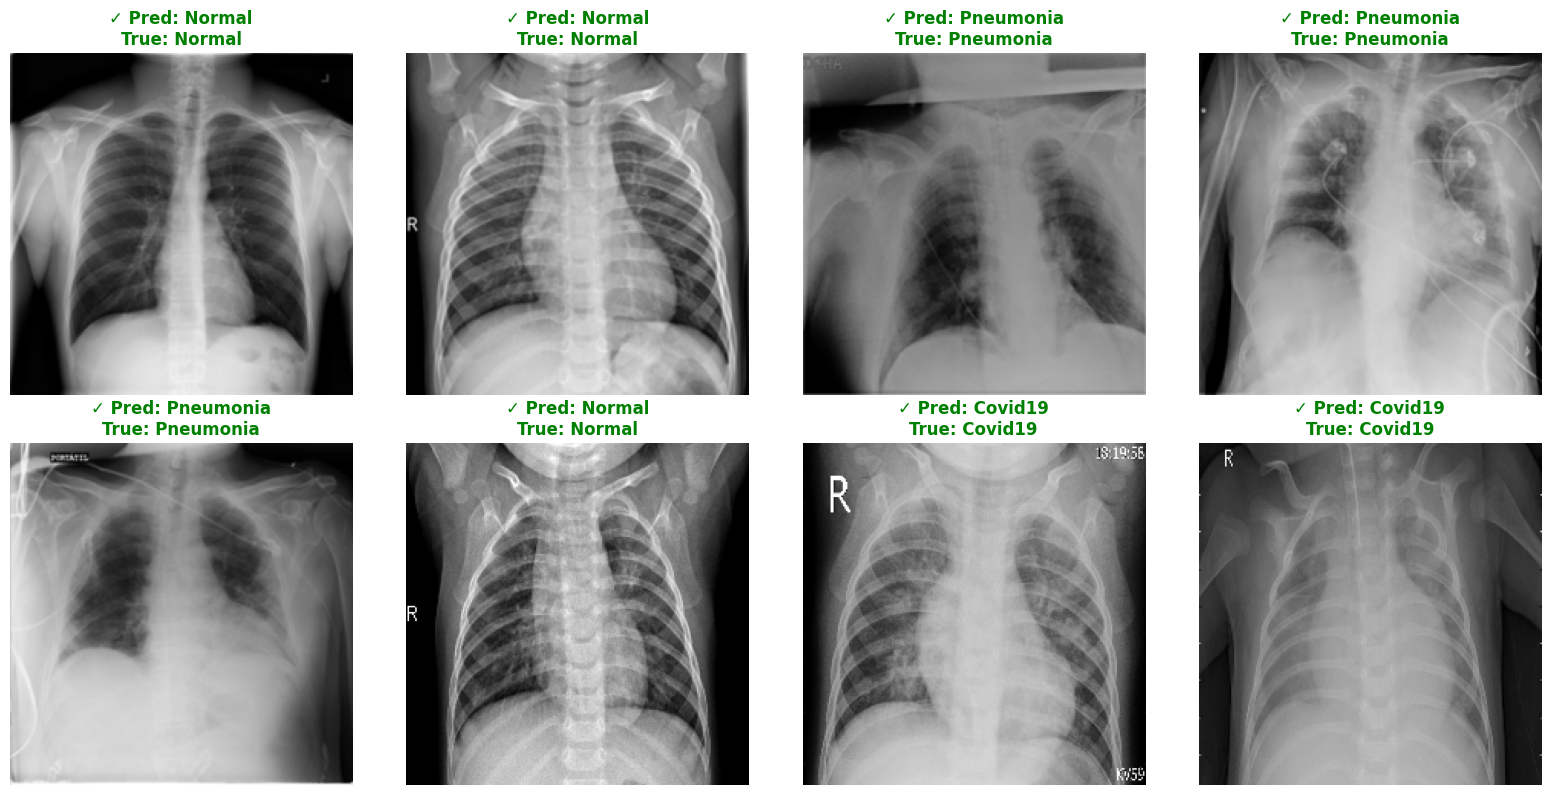

In [37]:
import matplotlib.pyplot as plt
import numpy as np

def display_predictions_from_loader(model, dataloader, class_names, device, n_samples=8):
    model.eval()
    images_shown = 0

    plt.figure(figsize=(16, 8))

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for i in range(inputs.size(0)):
                if images_shown >= n_samples:
                    break

                # Convert tensor -> numpy image
                img = inputs[i].cpu().permute(1, 2, 0).numpy()

                # Nếu có normalize thì UN-normalize (quan trọng)
                img = np.clip(img, 0, 1)

                true_label = class_names[labels[i].item()]
                pred_label = class_names[preds[i].item()]

                if labels[i] == preds[i]:
                    color = 'green'
                    mark = '✓'
                else:
                    color = 'red'
                    mark = '✗'

                plt.subplot(2, 4, images_shown + 1)
                plt.imshow(img)
                plt.axis('off')
                plt.title(
                    f"{mark} Pred: {pred_label}\nTrue: {true_label}",
                    color=color,
                    fontsize=12,
                    fontweight='bold'
                )

                images_shown += 1

            if images_shown >= n_samples:
                break

    plt.tight_layout()
    plt.show()

display_predictions_from_loader(
    model=loaded_model,
    dataloader=test_loader,
    class_names=label_names,
    device=device,
    n_samples=8
)
